# Portfolio Project Alex

In [21]:
# Import Libraries
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline 
# This displays plots right below the cell executing it and not in separate window
# But this version of jupyter notebook has this feature by default when we import pyplot
matplotlib.rcParams['figure.figsize'] = (12, 8) # Adjusts the configuration of the plots we will create


In [179]:
# Reading the data
file_path = 'portfolio_project/data/movies.csv'
df = pd.read_csv(file_path)

In [19]:
# Look at the data
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [20]:
# Ceck for missing data
df.isnull().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [28]:
df.loc[df['budget'].isnull()]['genre'].value_counts()

genre
Comedy       735
Drama        638
Action       278
Crime        146
Biography    128
Adventure     98
Animation     59
Horror        58
Family         7
Thriller       7
Romance        5
Mystery        3
Fantasy        2
Sci-Fi         2
Musical        2
Western        1
Music          1
Sport          1
Name: count, dtype: int64

In [279]:
# Not working as pandas cannot handle infinity values
# So to make it work we just need to pass Int64 not int64 i.e. capital 'I'
# Changing the data type of Budget and gross column
# df['budget'] = df['budget'].astype('int64')
# df['gross'] = df['gross'].astype('int64')

In [59]:
# Index of rows where budget and gross both are null
index_bug_gro_null = df[(df['budget'].isnull()) & (df['gross'].isnull())][['budget', 'gross']].index

In [60]:
df.shape

(7668, 15)

In [181]:
# Separating out year from released date
df['released'] = df['released'].astype(str)
df['year_released'] = df['released'].str.split(' ', expand=True)[2]

In [73]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0,2020
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0,2020
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN,2020
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0,2020


In [81]:
# About 1356 rows have mismatched year with released year
# df.loc[df['year'].astype(str) != df['year_released']]

In [190]:
# Displaying all rows
pd.set_option('display.max_rows', 50)

In [180]:
# Sorting dataset by gross 
df = df.sort_values(by=['gross'], inplace=False, ascending=False)

In [86]:
# Looking for duplicate values but not deleting one
df['company'].drop_duplicates().sort_values(ascending=False)

7129                                thefyzz
5664                            micro_scope
6412               iDeal Partners Film Fund
4007                               i5 Films
6793                             i am OTHER
                       ...                 
3748                     1+2 Seisaku Iinkai
3024                        .406 Production
7525    "Weathering With You" Film Partners
4345        "DIA" Productions GmbH & Co. KG
408                                     NaN
Name: company, Length: 2386, dtype: object

In [132]:
names = (df['name'].value_counts())
names.head(10)

name
Nobody's Fool      3
Pulse              3
Hercules           3
Fever Pitch        3
Hamlet             3
Venom              3
Anna               3
Friday the 13th    2
Ghostbusters       2
The Karate Kid     2
Name: count, dtype: int64

In [133]:
# Names of movies that are duplicates, there are 149 of them
# But their year of release is different
name_list = []
for name, freq in dict(names).items():
    if freq > 1:
        name_list.append(name)

# name_list

In [151]:
# df.loc[df['name'] == 'The Karate Kid']

In [182]:
# Dropping Year column
df = df.drop(columns='year')

In [185]:
# Converted both budget and gross column to Int64 (capital "I")  
# so that we don't have scientific notation for large values
# df['budget'] = df['budget'].astype('Int64')
# df['gross'] = df['gross'].astype('Int64')
# df['budget'] = df['budget'].replace([np.inf, -np.inf], np.nan)

In [139]:
# Guesses (Will see after actual correlation)
# Budget might have high correlation
# Company might have high correlation

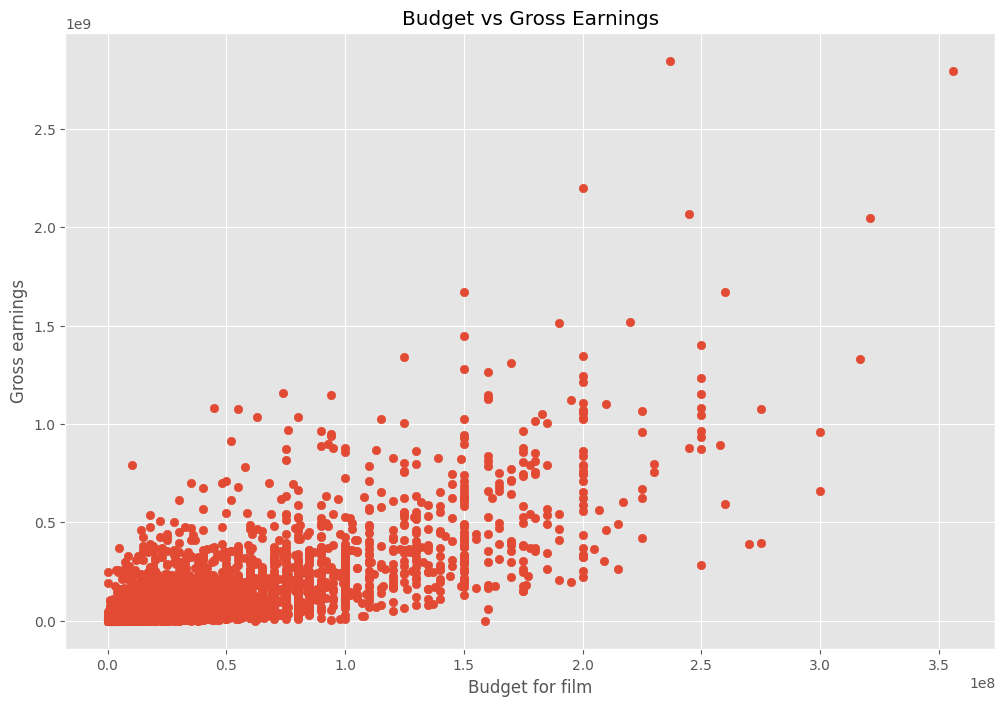

In [158]:
# Scatter plot with budget vs gross

plt.scatter(x=df['budget'], y=df['gross'])
plt.title('Budget vs Gross Earnings')
plt.xlabel('Budget for film')
plt.ylabel('Gross earnings')
plt.show()



In [157]:
df.head()

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released
5445,Avatar,PG-13,Action,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018


<Axes: xlabel='budget', ylabel='gross'>

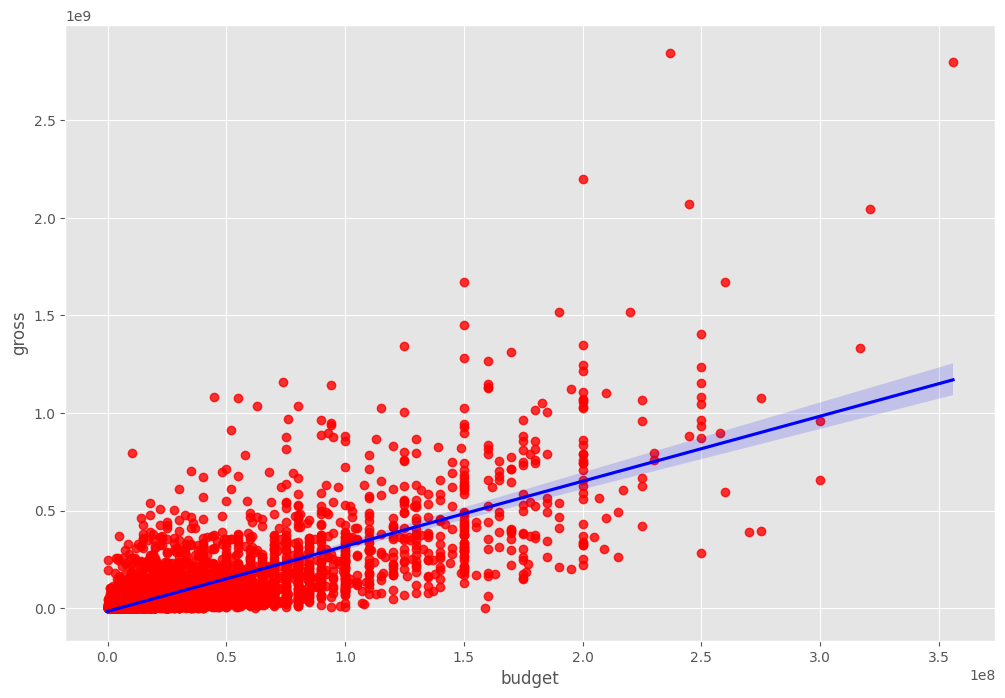

In [161]:
# To get better idea of correlation

sns.regplot(x='budget', y='gross', data=df, scatter_kws={'color': 'red'}, line_kws={'color':'blue'})

In [173]:
# Looking at correlation
df.corr(numeric_only=True) # Correlation types: pearson, kendall, spearman

,score,votes,budget,gross,runtime
score,1.000000,0.409182,0.076254,0.186258,0.399451
votes,0.409182,1.000000,0.442429,0.630757,0.309212
budget,0.076254,0.442429,1.000000,0.740395,0.320447
gross,0.186258,0.630757,0.740395,1.000000,0.245216
runtime,0.399451,0.309212,0.320447,0.245216,1.000000


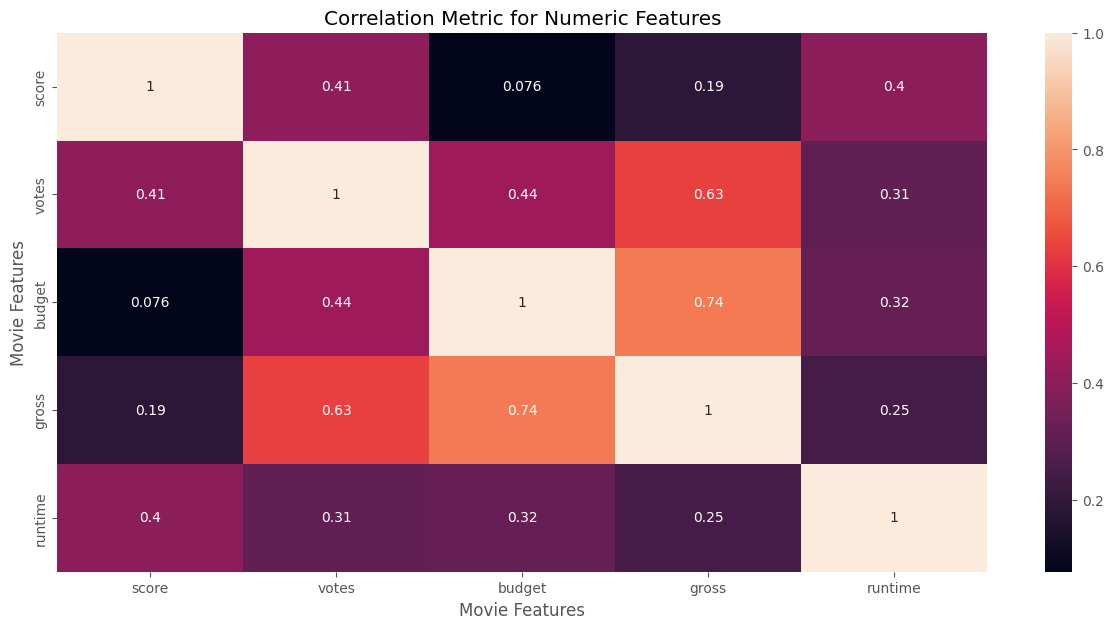

In [175]:
# Heat map to plot correlation
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True)
plt.rcParams['figure.figsize'] = (15, 7)

# Labels and Title
plt.title('Correlation Metric for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')

plt.show()

#### Heat Map inference
This heatmap provides a high-level view of how different movie metrics relate to one another. As a data analyst, here are the key takeaways I see from this correlation matrix:
1. The "Big Budget = Big Revenue" Trend
The strongest relationship in this entire dataset is between budget and gross (0.74).

* Insight: This is a strong positive correlation. It confirms the industry standard that higher financial investment generally leads to higher box office returns. If you are building a predictive model for revenue, budget is your most important feature.

2. Popularity is a Proxy for Success
There is a significant correlation between votes and gross (0.63).

* Insight: Movies that "trend" or have high audience engagement (votes) are much more likely to be high earners. This suggests that public interest/marketing reach is a better predictor of gross revenue than the actual quality (score) of the film.

3. Money Can't Buy a Good "Score"
One of the most interesting findings is the near-zero correlation between budget and score (0.076).

* Insight: Spending more money on a movie has almost no impact on its final rating or critical reception. A blockbuster budget doesn't guarantee a "good" movie; it only helps with scale and revenue.

4. Quality vs. Engagement
There is a moderate correlation (0.41) between score and votes.

* Insight: Better-rated movies tend to attract more voters. This makes sense—people are more likely to watch and review a movie that is highly recommended or critically acclaimed.

5. Runtime Observations
The correlation between runtime and score (0.4) is higher than the correlation between runtime and gross (0.25).

* Insight: This suggests that longer movies are often perceived as "better" or more substantial (perhaps prestige dramas or epics), but their length doesn't necessarily translate into a massive box office hit as directly as budget does.

------------------------------
Summary for your Analysis:
If your goal is to predict Gross Revenue, you should focus on Budget and Votes. However, if you are looking for what makes a highly-rated movie, budget is irrelevant, and you'd need to look at other features not captured here (like genre, director, or cast).
Since you were dealing with large numbers earlier (like that 2.84 billion value), it’s clear you’re looking at the "Gross" or "Budget" columns for some of the biggest blockbusters ever made.
Would you like to see how to visualize a scatter plot for the Budget vs. Gross relationship to see if there are any major outliers?



In [176]:
# look at company
df.head()

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released
5445,Avatar,PG-13,Action,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018


In [177]:
# Making companies numierc 
df_numerized = df.copy()

for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes

df_numerized

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released
5445,533,5,0,696,7.8,1100000.0,1155,1778,2334,55,237000000,2847246203,2253,162.0,31
7445,535,5,0,183,8.4,903000.0,162,743,2241,55,356000000,2797501328,1606,181.0,41
3045,6896,5,6,704,7.8,1100000.0,1155,1778,1595,55,200000000,2201647264,2253,194.0,19
6663,5144,5,0,698,7.8,876000.0,1125,2550,524,55,245000000,2069521700,1540,138.0,37
7244,536,5,0,192,8.4,897000.0,162,743,2241,55,321000000,2048359754,1606,149.0,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,3705,-1,6,2964,3.1,18.0,1500,2289,2421,55,7000,<NA>,-1,90.0,42
7664,1678,-1,4,1107,4.7,36.0,774,2614,1886,55,<NA>,<NA>,539,90.0,42
7665,4717,-1,6,193,5.7,29.0,2061,2683,2040,55,58750,<NA>,941,NaN,42
7666,2843,-1,6,2817,NaN,NaN,1184,1824,450,55,15000,<NA>,-1,120.0,42


In [280]:
df.head()

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released
5445,Avatar,PG-13,Action,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018


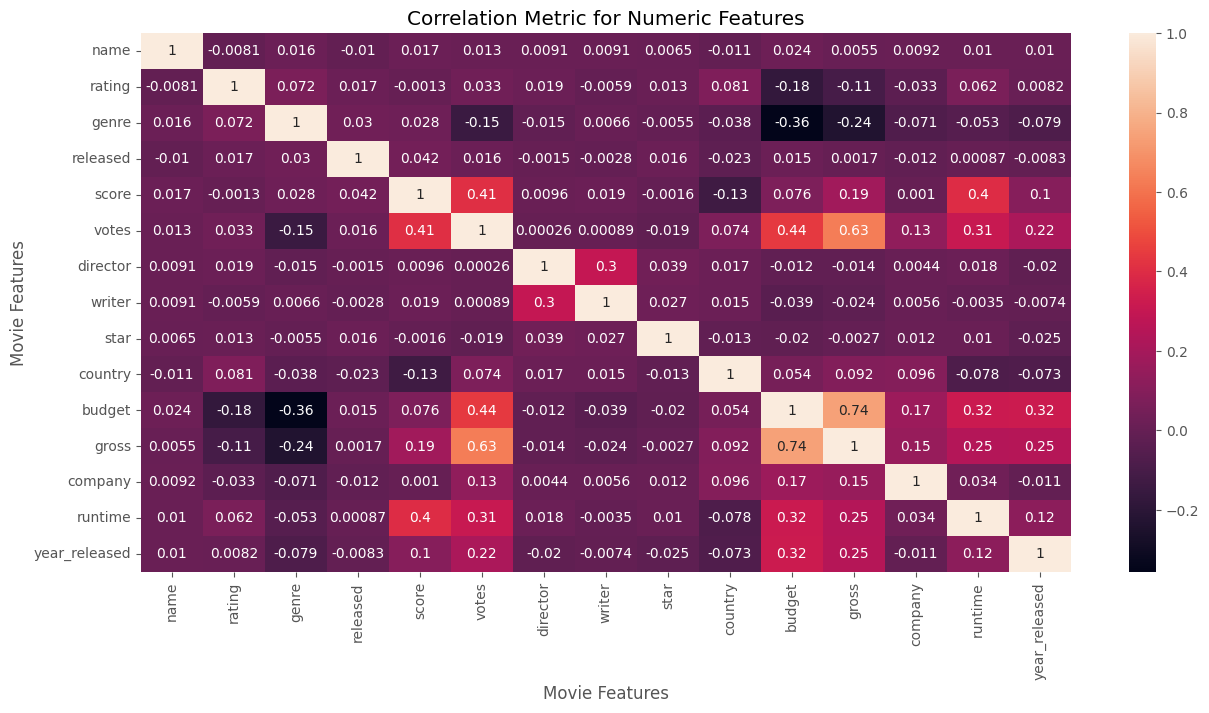

In [187]:
# Plotting heat map for numerized data frame
# Heat map to plot correlation
correlation_matrix = df_numerized.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True)
plt.rcParams['figure.figsize'] = (15, 7)

# Labels and Title
plt.title('Correlation Metric for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')

plt.show()

In [188]:
df_numerized.corr()

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released
name,1.000000,-0.008069,0.016355,-0.010480,0.017097,0.013088,0.009079,0.009081,0.006472,-0.010737,0.023970,0.005533,0.009211,0.010392,0.010071
rating,-0.008069,1.000000,0.072423,0.017208,-0.001314,0.033225,0.019483,-0.005921,0.013405,0.081244,-0.176002,-0.107339,-0.032943,0.062145,0.008230
genre,0.016355,0.072423,1.000000,0.030429,0.027965,-0.145307,-0.015258,0.006567,-0.005477,-0.037615,-0.356564,-0.235650,-0.071067,-0.052711,-0.078972
released,-0.010480,0.017208,0.030429,1.000000,0.042148,0.016154,-0.001526,-0.002784,0.015805,-0.023408,0.014683,0.001659,-0.012269,0.000868,-0.008287
score,0.017097,-0.001314,0.027965,0.042148,1.000000,0.409182,0.009559,0.019416,-0.001609,-0.133348,0.076254,0.186258,0.001030,0.399451,0.103330
votes,0.013088,0.033225,-0.145307,0.016154,0.409182,1.000000,0.000260,0.000892,-0.019282,0.073625,0.442429,0.630757,0.133204,0.309212,0.218468
director,0.009079,0.019483,-0.015258,-0.001526,0.009559,0.000260,1.000000,0.299067,0.039234,0.017490,-0.012272,-0.014441,0.004404,0.017624,-0.019692
writer,0.009081,-0.005921,0.006567,-0.002784,0.019416,0.000892,0.299067,1.000000,0.027245,0.015343,-0.039451,-0.023519,0.005646,-0.003511,-0.007400
star,0.006472,0.013405,-0.005477,0.015805,-0.001609,-0.019282,0.039234,0.027245,1.000000,-0.012998,-0.019589,-0.002717,0.012442,0.010174,-0.025231
country,-0.010737,0.081244,-0.037615,-0.023408,-0.133348,0.073625,0.017490,0.015343,-0.012998,1.000000,0.054063,0.092129,0.095548,-0.078412,-0.072682


## Taken the help of AI to convert non-numeric columns to category in a correct way.
- I have done so because the approach with which we had converted non-numeric columns into numbers was wrong.

In [224]:
# # 1. Always create a true copy to protect your raw dataset
# df_clean = df.copy()

# # 2. Apply One-Hot Encoding to the 'genre' column
# # drop_first=False keeps all genres visible in the heatmap for easier reading
# df_ohe = pd.get_dummies(df_clean, columns=['genre'], drop_first=False)

In [225]:
# df_ohe

In [226]:
# 1. Ensure we are working with our clean copy
df_target_encoded = df.copy()

# Drop any row that is missing data in either the 'budget' or 'gross' columns
df_target_encoded = df_target_encoded.dropna(subset=['budget', 'gross'])

# Check how many rows we have left to ensure we still have a healthy sample size
# print(f"Rows remaining after financial cleanup: {len(df_target_encoded)}")

# 2. Target Encode 'director' based on 'gross'
director_historical_gross = df_target_encoded.groupby('director')['gross'].mean()
df_target_encoded['director_encoded'] = df_target_encoded['director'].map(director_historical_gross)

# 3. Target Encode 'company' based on 'gross'
company_historical_gross = df_target_encoded.groupby('company')['gross'].mean()
df_target_encoded['company_encoded'] = df_target_encoded['company'].map(company_historical_gross)

# Now, you can safely drop the original text columns before running your correlation
# columns_to_drop = ['name', 'director', 'writer', 'star', 'country', 'company', 'genre']
# df_final_numeric = df_target_encoded.drop(columns=columns_to_drop, errors='ignore')

In [288]:
# To check whether the mapping happened correctly
# df_target_encoded['director_encoded'].sort_values(ascending=True)

In [289]:
# director_historical_gross.sort_values(ascending=True)

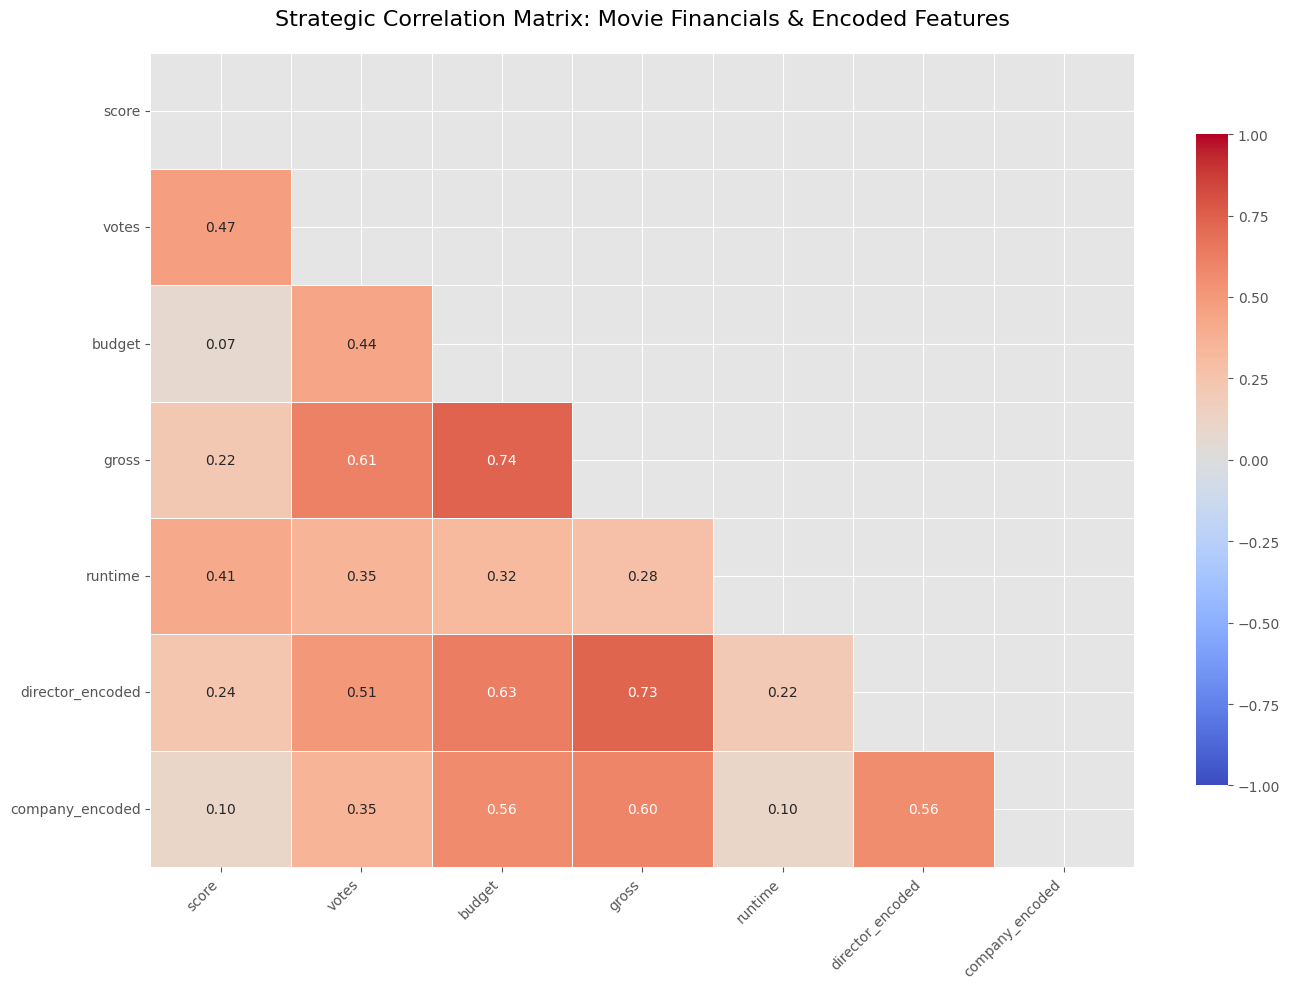

In [230]:
# 1. Calculate the Pearson correlation matrix
corr_matrix = df_target_encoded.corr(numeric_only=True)

# 2. Create a mask to hide the upper triangle (removes duplicate visual clutter)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Set up the matplotlib figure size
plt.figure(figsize=(14, 10))

# 4. Generate the polished heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,               # Applies the mask we created
    annot=True,              # Shows the correlation numbers
    fmt=".2f",               # Rounds numbers to exactly 2 decimal places for readability
    cmap="coolwarm",         # Professional diverging palette (red=positive, blue=negative)
    vmin=-1, vmax=1,         # Anchors the color scale strictly from -1 to 1
    linewidths=0.5,          # Adds clean white lines between the squares
    cbar_kws={"shrink": .8}  # Scales the color legend nicely
)

# 5. Add a professional title and adjust labels
plt.title('Strategic Correlation Matrix: Movie Financials & Encoded Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Angles bottom labels so they don't overlap
plt.yticks(rotation=0)              # Keeps side labels horizontal

# Display the chart
plt.tight_layout()
plt.show()

In [290]:
pd.set_option('display.max_rows', 50)

# Unstacking using numerized  dataset created above
correlation_mat = df_target_encoded.corr(numeric_only=True)

corr_pairs = correlation_mat.unstack()

# corr_pairs

In [291]:
# Creating sorted pairs in descending order
sorted_pairs = corr_pairs.sort_values(ascending=False)

In [292]:
# Getting values above 0.5 and below 1 as 1's are pairs of themselves
high_corr = sorted_pairs[(sorted_pairs > 0.5) & (sorted_pairs < 1)]

# Pairs are repeating themselves so displaying single values
high_corr_final = high_corr.iloc[list(range(0, 16, 2))]

In [293]:
# Missing values on the left are company_enco
high_corr_final

budget            gross               0.740395
director_encoded  gross               0.729882
budget            director_encoded    0.627648
votes             gross               0.614904
company_encoded   gross               0.596993
                  budget              0.562888
                  director_encoded    0.557868
votes             director_encoded    0.507740
dtype: float64

### Though the above code worked well, took the help of AI to make it clean an scalable

In [273]:
# Create the correlation matrix
corr_matrix = df_final_numeric.corr(numeric_only=True)

# Keep only the upper triangle by masking the lower triangle
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Unstack, drop the NaNs, and sort
sorted_pairs = upper_tri.unstack().dropna().sort_values(ascending=False)

# Filter for strong correlations
high_corr = sorted_pairs[sorted_pairs > 0.5]

In [277]:
high_corr

gross             budget              0.740395
director_encoded  gross               0.736732
gross             votes               0.630757
director_encoded  budget              0.623270
company_encoded   gross               0.604121
                  director_encoded    0.570778
                  budget              0.558988
director_encoded  votes               0.529671
dtype: float64

### 📊 Key Business Insights: The Blockbuster Formula
By filtering our correlation matrix for statistically significant relationships (coefficient > 0.5), we identified the core drivers of cinematic profitability. The data reveals that high grossing movies are not accidental; they are the result of a highly interconnected triad of capital, talent, and studio backing.

1. The "Big Two" Revenue Drivers: The total box office gross is heavily dictated by two nearly equal factors: Production Budget (0.74) and the Director's Historical Success (0.73). This indicates that while spending money is crucial, pairing that budget with a commercially proven director is an equally powerful predictor of financial return.

2. The Ecosystem of High-Budget Filmmaking:
There is a strong correlation between budget and director_encoded (0.63), as well as company_encoded and budget (0.56). This proves the industry operates in a closed-loop system: major studios (Companies) entrust their largest financial assets (Budgets) specifically to historically proven creatives (Directors).

3. The Audience Buzz Factor:
Audience engagement (votes) strongly correlates with gross (0.61). Interestingly, a proven director drives audience buzz (votes vs director = 0.51) much more effectively than the studio's brand name.

#### Strategic Conclusion:
To maximize box office revenue, a studio cannot simply increase the budget of an unknown property. The most risk-averse commercial strategy is to secure a director with a high-grossing track record, back them with a major studio's infrastructure, and allocate a top-tier budget.